In [1]:
# Import Library
import kagglehub
import os
import re
import ast
import nltk  # type: ignore
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from collections import Counter
from nltk.corpus import stopwords # type: ignore
from nltk.tokenize import word_tokenize # type: ignore
from sklearn.model_selection import train_test_split
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory  # type: ignore
from sklearn.feature_extraction.text import TfidfVectorizer
from imblearn.over_sampling import SMOTE # type: ignore
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score, accuracy_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import StratifiedKFold

# Tahap 1: Akuisisi & Eksplorasi Data
Stratified Sampling, Pelabelan Data, Analisis Imbalance dan Veracity awal.

In [2]:
# Download Dataset
path = kagglehub.dataset_download('farhan999/tokopedia-product-reviews')
print('Lokasi dataset:', path)

Lokasi dataset: /home/miku/.cache/kagglehub/datasets/farhan999/tokopedia-product-reviews/versions/2


In [3]:
# List file yang ada
for dirname, _, filenames in os.walk(path):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/home/miku/.cache/kagglehub/datasets/farhan999/tokopedia-product-reviews/versions/2/tokopedia-product-reviews-2019.csv


## Memuat dan Inspeksi Data
<h4>Memastikan data terbaca dan mengidentifikasi kolom ulasan (text) dan kolom rating (label)

In [4]:
# Pengaturan tampilan Pandas
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_colwidth', 100)
pd.set_option('display.width', 1000)

# Simpan path
csv_file_path = os.path.join(path, 'tokopedia-product-reviews-2019.csv')

# Cek file terbaca atau tidak
if os.path.exists(csv_file_path):
    df = pd.read_csv(csv_file_path)
    print("Berhasil load data!")
    print(df.head())
else:
    print(f"File tidak ditemukan di: {csv_file_path}")

Berhasil load data!
   Unnamed: 0                                             text  rating     category                                                            product_name  product_id sold  shop_id                                                                                          product_url
0           1           Barang sesuai pesanan dan cepat sampai       5  pertukangan  Staples Dekorasi Staples Kayu + Refill 8mm - Staples Gun 4-8 mm C Mart   418660637    1  1740837  https://www.tokopedia.com/shakaonline87/staples-dekorasi-staples-kayu-refill-8mm-staples-gun-4-8...
1           2                         Barang bagus harga murah       5  pertukangan          STAPLE GUN ATS 3 WAY TACKER - STAPLES JOK TEMBAK HEKTER 022708   416032545   11  1477109  https://www.tokopedia.com/juraganperkakas/staple-gun-ats-3-way-tacker-staples-jok-tembak-hekter-...
2           3  Paket rapi...mantap....cepat....sampe ke tujuan       5  pertukangan          STAPLE GUN ATS 3 WAY TACKER - STAPLES 

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40607 entries, 0 to 40606
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Unnamed: 0    40607 non-null  int64 
 1   text          40607 non-null  object
 2   rating        40607 non-null  int64 
 3   category      40607 non-null  object
 4   product_name  40607 non-null  object
 5   product_id    40607 non-null  int64 
 6   sold          40593 non-null  object
 7   shop_id       40607 non-null  int64 
 8   product_url   40607 non-null  object
dtypes: int64(4), object(5)
memory usage: 2.8+ MB


In [6]:
print(f"Total Data Awal adalah {len(df)} ulasan")

Total Data Awal adalah 40607 ulasan


In [7]:
# Mengcari data sampel dengan reveiw pendek
## Buat kolom 'num_words' untuk menyimpan jumlah angka
df2 = df.copy()
df2['num_words'] = df['text'].apply(lambda x: len(str(x).split()))

# Mencari 5 contoh review positif (rating 5) pendek dengan 3-6 kata
print("=== CALON SAMPEL POSITIF ===")
calon_positif = df2[(df2['rating'] == 5) & (df2['num_words'] >= 3) & (df2['num_words'] <= 6)][['text', 'rating']].head(5)
print(calon_positif)

print("\n" + "="*30 + "\n")

# Mencari 5 contoh review negatif (rating 1 atau 2) pendek dengan 3-6 kata
print("=== CALON SAMPEL NEGATIF ===")
calon_negatif = df2[(df2['rating'] <= 2) & (df2['num_words'] >= 3) & (df2['num_words'] <= 6)][['text', 'rating']].head(5)
print(calon_negatif)

=== CALON SAMPEL POSITIF ===
                                              text  rating
0           Barang sesuai pesanan dan cepat sampai       5
1                         Barang bagus harga murah       5
2  Paket rapi...mantap....cepat....sampe ke tujuan       5
3                       ya saya puas dgn barangnya       5
4                     Responya luar biasa b mantap       5


=== CALON SAMPEL NEGATIF ===
                                        text  rating
93    barang yg dikirim tidak sesuai pesanan       1
313        brg sdh diterima.................       2
1066           Barangnya rusak..kecewa berat       1
1236             Beli 5 tdk bs dipakai semua       1
2346               Ada 1 bagian yg tidak ada       1


## Cek & Hapus Duplikasi

In [8]:
# hapus jika kolom 'text' isinya sama persis
initial_len = len(df)
df = df.drop_duplicates(subset='text')
print(f"Ditemukan {initial_len - len(df)} data duplikat/spam.")
print(f"Total Data Unik: {len(df)} baris")

Ditemukan 3306 data duplikat/spam.
Total Data Unik: 37301 baris


## Pelabelan Ulang (Mapping Rating ke Sentimen)
<h4>Naive Bayes biasanya mengklasifikasikan ke 3 kelas (Positif, Netral, Negatif), kita perlu me-mapping rating (1-5) menjadi 3 kelas.</h4>

In [9]:
def map_sentiment(rating):
    if rating in [4, 5]:
        return 'Positif'
    elif rating == 3:
        return 'Netral'
    elif rating in [1, 2]:
        return 'Negatif'

df['Sentiment_Label'] = df['rating'].apply(map_sentiment)

In [10]:
print(df[['rating', 'Sentiment_Label']].sample(5))

       rating Sentiment_Label
1763        4         Positif
35647       4         Positif
38408       5         Positif
34159       1         Negatif
6625        3          Netral


## Menghitung Distribusi Awal
<h4>Mendapatkan angka pasti untuk populasi sebelum sampling 20.000. Angka ini juga menunjukkan apakah terjadi Imbalance Class.</h4>

In [11]:
# Hitung jumlah dan persentase
dist_count = df['Sentiment_Label'].value_counts()
dist_perc = df['Sentiment_Label'].value_counts(normalize=True) * 100

# Gabungkan dan tampilkan
dist_df = pd.DataFrame({'Jumlah': dist_count, 'Persentase (%)': dist_perc.round(2)})
print("\\nDistribusi Sentimen Populasi Awal:")
print(dist_df)

\nDistribusi Sentimen Populasi Awal:
                 Jumlah  Persentase (%)
Sentiment_Label                        
Positif           34628           92.83
Netral             1762            4.72
Negatif             911            2.44


## Stratified Sampling ke 20.000 Sampel
<h4>Mengambil sampel 20.000 data yang proporsi sentimennya sama dengan data 40.000 awal (ini adalah teknik Stratified Sampling)</h4>

In [12]:
# Ambil sampel HANYA jika data unik masih > 20.000
N_TARGET = 20000

if len(df) > N_TARGET:
  # Hitung sisa yang harus dibuang
  test_size_ratio = 1 - (N_TARGET / len(df))

  # Split
  print("\nMelakukan Stratified Sampling ke 20.000 data...")
  df_sample, _ = train_test_split(
      df,
      test_size=test_size_ratio,
      random_state=42,
      stratify=df['Sentiment_Label']
  )
else:
  print(f"\nData unik kurang dari {N_TARGET}, menggunakan seluruh data yang ada.")
  df_sample = df.copy()


Melakukan Stratified Sampling ke 20.000 data...


## Cleaning Ringan & Visualisasi Distribusi

In [13]:
# Pembersihan Kolom yang tidak digunakan
print("Jumlah kolom sebelum drop:", len(df_sample.columns))

# Mengambil hanya kolom yang relevan untuk NLP
df_sample = df_sample[['text', 'rating', 'Sentiment_Label']].copy()

# Reset index agar rapi
df_sample = df_sample.reset_index(drop=True)

print("Jumlah kolom setelah drop:", len(df_sample.columns))
print("\\n=== Data Sampel Akhir ===")
df_sample.head()

Jumlah kolom sebelum drop: 10
Jumlah kolom setelah drop: 3
\n=== Data Sampel Akhir ===


,text,rating,Sentiment_Label
0,Barang sesuai orderan dan kondisi bagus,5,Positif
1,Nice gan keren produknya. Maju terus yaaaa,5,Positif
2,Baranh bagus.cma blm bisa merangkainya,5,Positif
3,barangnya bagus sesuai harga...,4,Positif
4,"Barang sdh mendarat dgn slmt, sedikit kecewa sih, ordernya merk firlan dikirimnya merk fleco..",4,Positif



Distribusi Sentimen Akhir:
  Sentimen  Jumlah  Persentase
0  Positif   18567      92.835
1   Netral     945       4.725
2  Negatif     488       2.440


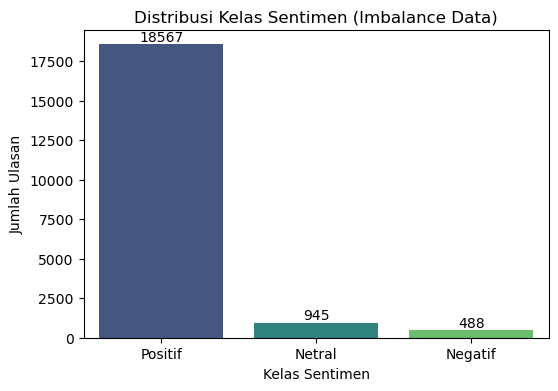

In [14]:
# Visualisasi Distribusi Data
## Tabel
dist_df = df_sample['Sentiment_Label'].value_counts().reset_index()
dist_df.columns = ['Sentimen', 'Jumlah']
dist_df['Persentase'] = (dist_df['Jumlah'] / len(df_sample)) * 100
print("\nDistribusi Sentimen Akhir:")
print(dist_df)

# Grafik Batang
plt.figure(figsize=(6, 4))
ax = sns.barplot(
    x='Sentimen',
    y='Jumlah',
    data=dist_df,
    hue='Sentimen',
    palette='viridis',
    legend=False
  )
plt.title('Distribusi Kelas Sentimen (Imbalance Data)')
plt.xlabel('Kelas Sentimen')
plt.ylabel('Jumlah Ulasan')

# Tambah label angka di atas batang
for i in ax.containers:
  ax.bar_label(i,)
plt.show()

In [15]:
# Simpan Data
# df_sample.to_csv('data_sample_20k.csv', index=False)
# print("Data sampel berhasil disimpan ke 'data_sample_20k.csv'")

In [16]:
# Load data
print("Sedang memuat data sample...")
df_sample = pd.read_csv('data_sample_20k.csv')

# Handling NaN
initial_len = len(df_sample)
df_sample = df_sample.dropna(subset=['text', 'Sentiment_Label'])

# paksa jadi string
df_sample['text'] = df_sample['text'].astype(str)

# cek data yang dibuang
if len(df_sample) != initial_len:
  print(f"Info: Ditemukan {initial_len - len(df_sample)} baris kosong/NaN dan telah dihapus.")
else:
  print("Info: Data bersih, tidak ada NaN.")

print(f"Total Data Siap Preprocessing: {len(df_sample)} baris")
df_sample.head()

Sedang memuat data sample...
Info: Data bersih, tidak ada NaN.
Total Data Siap Preprocessing: 20000 baris


,text,rating,Sentiment_Label
0,Barang sesuai orderan dan kondisi bagus,5,Positif
1,Nice gan keren produknya. Maju terus yaaaa,5,Positif
2,Baranh bagus.cma blm bisa merangkainya,5,Positif
3,barangnya bagus sesuai harga...,4,Positif
4,"Barang sdh mendarat dgn slmt, sedikit kecewa sih, ordernya merk firlan dikirimnya merk fleco..",4,Positif


# Tahap 2: Pra-pemrosesan Data dan Rekayasa Fitur

## A. Preprocessing

### 1. Mencari Kata Slang

In [17]:
# Fungsi cleaning cepat
def quick_clean_check(text):
  text = str(text).lower()
  text = re.sub(r'[^a-z\s]', ' ', text) # Hapus angka & simbol
  return re.sub(r'\s+', ' ', text).strip()

# Terapkan ke df_sample
print("Sedang menghitung frekuensi kata ...")
all_text_sample = df_sample['text'].apply(quick_clean_check)

# Gabung semua teks jadi satu string raksasa & pecah jadi list kata
all_words = ' '.join(all_text_sample).split()
word_counts = Counter(all_words)

df_top_500 = pd.DataFrame(word_counts.most_common(500), columns=['Kata', 'Frekuensi'])

print("--- MENAMPILKAN TOP 500 KATA PER HALAMAN ---")

# Loop setiap 50 baris
for i in range(0, 500, 50):
    print(f"\n>>> Urutan {i+1} sampai {i+50} <<<")
    # Tampilkan blok data
    print(df_top_500.iloc[i : i+50])
    print("-" * 40) # Garis pemisah biar rapi

Sedang menghitung frekuensi kata ...
--- MENAMPILKAN TOP 500 KATA PER HALAMAN ---

>>> Urutan 1 sampai 50 <<<
           Kata  Frekuensi
0        barang       7643
1        sesuai       5640
2         cepat       4474
3           dan       4100
4         bagus       3836
5        dengan       2723
6         sudah       2664
7    pengiriman       2296
8        sampai       2265
9          baik       2109
10       terima       2030
11       respon       1971
12          gan       1908
13           di       1850
14        kasih       1627
15       produk       1600
16       seller       1501
17      pesanan       1496
18       mantap       1476
19          nya       1375
20     diterima       1294
21    deskripsi       1291
22      packing       1252
23           ok       1212
24           yg       1202
25       thanks       1094
26         saya       1021
27    barangnya       1003
28       sangat        930
29          oke        920
30        harga        919
31     kualitas        904

In [18]:
#from google.colab import drive
#drive.mount('/content/drive')

### 2. Membuat Kamus Slang (Berdasarkan Frekuensi Kata)

In [19]:
# Setup Kamus Slang (FINAL VERSION: TOP 500 FREQUENCY)
import pandas as pd

slang_data = {
    'slang': [
        # --- BAGIAN 1: Singkatan & Typo Umum (Urutan 1-200) ---
        'd', 'dg', 'jg', 'n', 'tq', 'tks', 'aja', 'deh', 'udh',
        'yg', 'dgn', 'gak', 'ga', 'krn', 'sdh', 'blm', 'thx',
        'brg', 'ori', 'bgs', 'mantul', 'mantab', 'gan', 'sis', 'kak',
        'bs', 'sy', 'tp', 'kalo', 'kl', 'karna', 'responya', 'packing',
        'cepet', 'sampe', 'trims', 'recomended', 'recommended', 'kwalitas',
        'makasih', 'pake', 'bgt', 'dr', 'dtg', 'rapih', 'oke', 'ok',
        'udah', 'nyampe', 'pokoknya', 'bos', 'sip', 'klo', 'nich', 'cuman',
        'boossku', 'bosku', 'retur', 'work', 'respon', 'resp', 'ttp',
        'smpai', 'barng', 'kuy', 'jgn', 'luarbiasa', 'gk', 'blom', 'ngak',
        'sesua', 'tdk', 'seblm', 'donk', 'trmksh', 'y', 'smpe', 'pekingnya',
        'gapapa', 'th', 'packingan', 'ato', 'mantapppppppppp', 'gannmmmmnmnn', 'brgnya',
        'cpt', 'utk', 'jd', 'sih', 'an', 'respond', 'overall', 'and', 'hp',
        'alhamdulillah', 'disini', 'thanks', 'thank', 'fast', 'good',
        'seller', 'best', 'slow', 'refund', 'response', 'original',
        'product', 'you', 'the power', 'delivery', 'amp', 'pdhl',

        # --- BAGIAN 2: Tambahan Baru (Urutan 201-500) ---
        # Variasi Terima Kasih & Sapaan
        'trimakasih', 'trima', 'mksh', 'makasi', 'thankyou', 'agan', 'boss', 'om', 'bro',

        # Singkatan Kata Sambung & Umum
        'lg', 'moga', 'smoga', 'mudahan', 'dr', 'dlm', 'tpi', 'tgl', 'dpt', 'dapet',
        'cm', 'g', 'u', 'it', 'ane', 'gpp', 'ny', 'klo', 'tu',

        # Kualitas & Kondisi
        'quality', 'baguss', 'bagusss', 'bgus', 'sipp', 'joss', 'markotop',
        'mantaap', 'mantapp', 'mantep', 'great', 'nice', 'okelah', 'mnrt',

        # Transaksi & Pengiriman
        'service', 'pesen', 'orderan', 'kiriman', 'nyampe', 'sampenya',
        'trus', 'dikirim', 'ngirim', 'recomend', 'rekomen', 'review',

        # Masalah & Emosi
        'nyesel', 'sorry', 'rusak', 'error', 'kcwa', 'kecewa', 'ancur',

        # Typo Spesifik Lainnya
        'brng', 'diskripsi', 'kabel', 'batre', 'baterai', 'cassan', 'casan',
        'ksh', 'kaya', 'ak', 'aq'
    ],
    'formal': [
        # --- MAPPING BAGIAN 1 (1-200) ---
        'di', 'dengan', 'juga', 'dan', 'terima kasih', 'terima kasih', 'saja', 'saja', 'sudah',
        'yang', 'dengan', 'tidak', 'tidak', 'karena', 'sudah', 'belum', 'terima kasih',
        'barang', 'asli', 'bagus', 'mantap betul', 'mantap', 'juragan', 'kakak', 'kakak',
        'bisa', 'saya', 'tapi', 'kalau', 'kalau', 'karena', 'responnya', 'pengemasan',
        'cepat', 'sampai', 'terima kasih', 'rekomendasi', 'rekomendasi', 'kualitas',
        'terima kasih', 'pakai', 'banget', 'dari', 'datang', 'rapi', 'baik', 'baik',
        'sudah', 'sampai', 'memang', 'juragan', 'bagus', 'kalau', 'ini', 'cuma',
        'juragan', 'juragan', 'pengembalian', 'berfungsi', 'respons', 'respons', 'tetap',
        'sampai', 'barang', 'yuk', 'jangan', 'luar biasa', 'tidak', 'belum', 'tidak',
        'sesuai', 'tidak', 'sebelum', 'dong', 'terima kasih', 'ya', 'sampai', 'pengemasannya',
        'tidak apa-apa', 'tahun', 'pengemasan', 'atau', 'mantap', 'juragan', 'barang',
        'cepat', 'untuk', 'jadi', 'saja', 'an', 'respons', 'secara keseluruhan', 'dan', 'handphone',
        'bersyukur', 'di sini', 'terima kasih', 'terima kasih', 'cepat', 'bagus',
        'penjual', 'terbaik', 'lambat', 'pengembalian dana', 'respons', 'asli',
        'produk', 'anda', 'kekuatan', 'pengiriman', 'dan', 'padahal',

        # --- MAPPING BAGIAN 2 (201-500) ---
        # Variasi Terima Kasih & Sapaan
        'terima kasih', 'terima kasih', 'terima kasih', 'terima kasih', 'terima kasih', 'juragan', 'juragan', 'paman', 'saudara',

        # Singkatan Kata Sambung & Umum
        'lagi', 'semoga', 'semoga', 'semoga', 'dari', 'dalam', 'tapi', 'tanggal', 'dapat', 'dapat',
        'cuma', 'tidak', 'kamu', 'itu', 'saya', 'tidak apa-apa', 'nya', 'kalau', 'itu',

        # Kualitas & Kondisi
        'kualitas', 'bagus', 'bagus', 'bagus', 'sip', 'mantap', 'mantap',
        'mantap', 'mantap', 'mantap', 'bagus', 'bagus', 'oke', 'menurut',

        # Transaksi & Pengiriman
        'layanan', 'pesan', 'pesanan', 'pengiriman', 'sampai', 'sampainya',
        'terus', 'kirim', 'kirim', 'rekomendasi', 'rekomendasi', 'ulasan',

        # Masalah & Emosi
        'menyesal', 'maaf', 'rusak', 'rusak', 'kecewa', 'kecewa', 'hancur',

        # Typo Spesifik Lainnya
        'barang', 'deskripsi', 'kabel', 'baterai', 'baterai', 'charger', 'charger',
        'kasih', 'seperti', 'aku', 'aku'
    ]
}

# Verifikasi sinkronisasi
if len(slang_data['slang']) != len(slang_data['formal']):
    print(f"FATAL ERROR: Jumlah slang ({len(slang_data['slang'])}) beda dengan formal ({len(slang_data['formal'])})!")
    # Tips debugging: cek list mana yang lebih panjang
else:
    pd.DataFrame(slang_data).to_csv('kamus_slang_skripsi.csv', index=False)
    print("File 'kamus_slang_skripsi.csv' berhasil diperbarui (Top 500 Frequent Words).")

# Load Dictionary
df_slang_load = pd.read_csv('kamus_slang_skripsi.csv')
# normalize: strip, lowercase
df_slang_load['slang'] = df_slang_load['slang'].astype(str).str.strip().str.lower()
df_slang_load['formal'] = df_slang_load['formal'].astype(str).str.strip().str.lower()
# 
multy_keys = df_slang_load[df_slang_load['slang'].str.contains(f'\s+')]
if len(multy_keys):
    print(f"Note: {len(multy_keys)} slang entries contain spaces and will be remove for token-level mapping.")
    df_slang_load = df_slang_load[~df_slang_load['slang'].str.contains(r'\s+')]
SLANG_DICT = dict(zip(df_slang_load['slang'], df_slang_load['formal']))
print(f"Kamus siap dipakai! Total kosakata: {len(SLANG_DICT)}")

File 'kamus_slang_skripsi.csv' berhasil diperbarui (Top 500 Frequent Words).
Note: 1 slang entries contain spaces and will be remove for token-level mapping.
Kamus siap dipakai! Total kosakata: 180


### 3. Eksekusi Preprocessing Utama

In [20]:
# --- FUNGSI PREPROCESSING FINAL (NO NEGATION HANDLING) ---
tqdm.pandas()

# Compile Regex (Biar ngebut)
URL_PATTERN = re.compile(r'https?://\S+|www\.\S+')
HTML_PATTERN = re.compile(r'<.*?>|&([a-z0-9]+|#[0-9]{1,6}|#x[0-9a-f]{1,6});')
NON_ALPHA_PATTERN = re.compile(r'[^a-z\s]')
WHITESPACE_PATTERN = re.compile(r'\s+')

def preprocessing_ngram_ready(text):
    # 1. Validasi
    if not isinstance(text, str):
        return ""
    
    # 2. Case Folding
    text = text.lower()
    
    # 3. Cleaning Regex
    text = URL_PATTERN.sub(' ', text)
    text = HTML_PATTERN.sub(' ', text)
    text = NON_ALPHA_PATTERN.sub(' ', text)
    
    # Hapus huruf berulang (baaaagus -> bagus)
    text = re.sub(r'([a-z])\1+', r'\1\1', text) 
    
    # 4. Normalisasi Slang (Tanpa Negation Handling)
    # Kita biarkan "tidak" dan "suka" terpisah.
    # Nanti Bigram yang akan menyatukannya jadi ["tidak suka"]
    words = text.split()
    normalized_words = [SLANG_DICT.get(word, word) for word in words]
    
    # Gabung lagi
    text = ' '.join(normalized_words)
    
    # 5. Final Cleaning spasi
    text = WHITESPACE_PATTERN.sub(' ', text).strip()
    
    return text

# Eksekusi
print("Mulai preprocessing (Mode N-Gram Optimization)...")
df_sample['text_clean'] = df_sample['text'].progress_apply(preprocessing_ngram_ready)
print("Selesai!")

Mulai preprocessing (Mode N-Gram Optimization)...


  0%|          | 0/20000 [00:00<?, ?it/s]

Selesai!


### 4. Verifikasi Hasil (Quality Control)

In [21]:
# Cek hasil sebelum lanjut ke Stemming
## Ambil sampel acak
pd.set_option('display.max_colwidth', 150)

print("=== PERBANDINGAN SEBELUM & SESUDAH CLEANING ===")
# Ambil sampel yang mengandung kata slang umum untuk dicek
cek_sample = df_sample[df_sample['text'].str.contains('brg|yg|gan', case=False, na=False)].sample(5)

print(cek_sample[['text', 'text_clean']])

# Cek apakah ada data yang jadi kosong (null/empty string)
empty_count = df_sample[df_sample['text_clean'] == ''].shape[0]
print(f"\nJumlah data yang menjadi kosong setelah cleaning: {empty_count}")

=== PERBANDINGAN SEBELUM & SESUDAH CLEANING ===
                                                                                                                                                        text                                                                                                                                             text_clean
4511                                                                                makasih gan, barang dah sampai, kualitas oke, kemasan oke. recsel deh...                                                                          terima kasih juragan barang dah sampai kualitas baik kemasan baik recsel saja
15997  barang sudah sampai, tapi bungkus dari earphone berbeda dengan yang ditampilkan di halaman penjualan, dan untuk earphone nya sendiri barang kw\n\n...  barang sudah sampai tapi bungkus dari earphone berbeda dengan yang ditampilkan di halaman penjualan dan untuk earphone nya sendiri barang kw kenap...
14679  mantaf walau sy lupa 

In [22]:
# Drop Empty Rows
import numpy as np

print(f"Baris sebelum di-drop: {len(df_sample)}")

# Menggunakan assignment langsung untuk mengganti string kosong menjadi NaN
df_sample['text_clean'] = df_sample['text_clean'].replace('', np.nan)

# Drop baris yang memiliki NaN pada kolom text_clean
df_sample = df_sample.dropna(subset=['text_clean'])

# Reset index agar tidak ada index yang loncat setelah di-drop
df_sample = df_sample.reset_index(drop=True)

print(f"Baris setelah di-drop: {len(df_sample)}")

Baris sebelum di-drop: 20000
Baris setelah di-drop: 19937


### 5. Tokenisasi & Stopword Removal

In [23]:
# Download resource NLTK
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')
    nltk.download('punkt')

# 1. Ambil daftar stopword bahasa Indonesia (Bawaan NLTK)
stop_words = set(stopwords.words('indonesian'))

# --- Pengecualian: jangan hapus kata negatif ---
negation_keep = {'tidak', 'tak', 'bukan', 'jangan', 'belum', 'kurang'}
for word in negation_keep:
    if word in stop_words:
        stop_words.remove(word)


# 2. Stopword Tambahan (Custom)
custom_stopwords = [
    'nya', 'an', 'deh', 'amp', 'ya', 'a',
    'sih', 'dong', 'tuh', 'lah', 'pun', 'yuk',
    'yang', 'dan', 'di', 'ke', 'dari', 'dg', 'rt' # Memastikan kata umum ini benar-benar terhapus
]

stop_words.update(custom_stopwords)

def remove_stopwords(text):
    # Validasi: Pastikan input string (jaga-jaga ada NaN nyelip)
    if not isinstance(text, str):
        return []

    # 1. Tokenisasi
    tokens = word_tokenize(text)

    # 2. Filtering
    filtered_words = [w for w in tokens if w not in stop_words]

    return filtered_words

# Eksekusi
print("Sedang membuang stopword...")
df_sample['text_tokens'] = df_sample['text_clean'].progress_apply(remove_stopwords)

# Cek hasil
print("\n=== HASIL TOKENISASI & STOPWORD REMOVAL ===")
print(df_sample[['text_clean', 'text_tokens']].head())

Sedang membuang stopword...


  0%|          | 0/19937 [00:00<?, ?it/s]


=== HASIL TOKENISASI & STOPWORD REMOVAL ===
                                                                                         text_clean                                                                        text_tokens
0                                                           barang sesuai pesanan dan kondisi bagus                                          [barang, sesuai, pesanan, kondisi, bagus]
1                                                      bagus juragan keren produknya maju terus yaa                                      [bagus, juragan, keren, produknya, maju, yaa]
2                                                          baranh bagus cma belum bisa merangkainya                                          [baranh, bagus, cma, belum, merangkainya]
3                                                                      barangnya bagus sesuai harga                                                  [barangnya, bagus, sesuai, harga]
4  barang sudah mendarat dengan slmt sed

### 6. Stemming (Sastrawi)

In [24]:
# Eksekusi Stemming dengan Dictionary Mapping
# 1. Buat Stemmer
factory = StemmerFactory()
stemmer = factory.create_stemmer()

# 2. Siapkan Wadah Kata Unik
# Ambil semua kata yang ada di kolok token, lalu dijadikan satu list raksasa
print("Mengumpulkan kata-kata unik...")
all_tokens = [word for tokens in df_sample['text_tokens'] for word in tokens]

# Pakai set() agar hanya menyimpan kata unik (no duplikat)
unique_tokens = list(set(all_tokens))
print(f"Total kata unik yang perlu di-stem: {len(unique_tokens)}")

# 3. Proses Stemming Kata Unik
# Buat kamus: {'kata_asal' : 'kata_dasar'}
stemmed_dict = {}

print("Mulai proses Stemming...")
for word in tqdm(unique_tokens):
  # Hanya stem jika belum ada dikamus
  stemmed_dict[word] = stemmer.stem(word)

# 4. Terapkan (Mapping) ke DataFrame
def apply_stemming_fast(tokens):
  # Ganti setiap kata di list dengan hasil stemming dari kamus
  return [stemmed_dict[word] for word in tokens]

print("Menerapkan hasil stemming ke DataFrame...")
df_sample['text_stemmed_list'] = df_sample['text_tokens'].progress_apply(apply_stemming_fast)

# 5. Gabungkan kembali jadi kalimat utuh (String) untuk persiapan TF-IDF
df_sample['text_final'] = df_sample['text_stemmed_list'].apply(lambda x: ' '.join(x))
print(df_sample[['text_clean', 'text_final']].head())

Mengumpulkan kata-kata unik...
Total kata unik yang perlu di-stem: 8684
Mulai proses Stemming...


  0%|          | 0/8684 [00:00<?, ?it/s]

Menerapkan hasil stemming ke DataFrame...


  0%|          | 0/19937 [00:00<?, ?it/s]

                                                                                         text_clean                                                   text_final
0                                                           barang sesuai pesanan dan kondisi bagus                            barang sesuai pesan kondisi bagus
1                                                      bagus juragan keren produknya maju terus yaa                          bagus juragan keren produk maju yaa
2                                                          baranh bagus cma belum bisa merangkainya                                baranh bagus cma belum rangka
3                                                                      barangnya bagus sesuai harga                                    barang bagus sesuai harga
4  barang sudah mendarat dengan slmt sedikit kecewa saja ordernya merk firlan dikirimnya merk fleco  barang darat slmt kecewa order merk firlan kirim merk fleco


In [25]:
# --- SIMPAN HASIL BERSIH ---

# Pilih kolom yang PENTING saja:
# 1. 'text': Buat manusia baca (debugging)
# 2. 'rating': Opsional, buat info tambahan
# 3. 'Sentiment_Label': Target (y)
# 4. 'text_final': Fitur Input Model (X)
columns_to_save = ['text', 'rating', 'Sentiment_Label', 'text_final']

# Filter kolom yang ada saja (jaga-jaga kalau 'rating' sudah didrop duluan)
final_columns = [col for col in columns_to_save if col in df_sample.columns]

# Buat dataframe baru versi ramping
df_save = df_sample[final_columns].copy()

# Hapus baris kosong jika ada sisa preprocessing yang jadi string kosong
df_save = df_save[df_save['text_final'].str.strip() != '']

# Simpan
filename = 'data_ulasan_stemmed.csv'
df_save.to_csv(filename, index=False)

print(f"File berhasil disimpan: {filename}")
print(f"Dimensi data: {df_save.shape}")
print(f"Kolom tersimpan: {list(df_save.columns)}")

File berhasil disimpan: data_ulasan_stemmed.csv
Dimensi data: (19857, 4)
Kolom tersimpan: ['text', 'rating', 'Sentiment_Label', 'text_final']


## Load Hasil Preprocessing

In [26]:
from sklearn.preprocessing import LabelEncoder

# 1. Load data
print("Loading data bersih...")
df_sample = pd.read_csv('data_ulasan_stemmed.csv')

print(f"Jumlah baris awal: {len(df_sample)}")

# 2. Validasi Kolom text_final (PENTING)
# Pastikan tipe datanya String (bukan float/NaN)
df_sample['text_final'] = df_sample['text_final'].astype(str)

# Hapus data yang kosong/NaN (Jaga-jaga ada yang lolos)
# Kita drop baris jika 'text_final' kosong atau 'Sentiment_Label' kosong
df_sample = df_sample[df_sample['text_final'].str.strip() != '']
df_sample = df_sample.dropna(subset=['Sentiment_Label'])

print(f"Jumlah baris siap pakai: {len(df_sample)}")

# 3. Encoding Label (Persiapan buat Masuk Model)
# Model ML gak bisa baca teks 'Positif'/'Negatif', harus angka 0, 1, 2
print("Mengubah label teks menjadi angka...")
le = LabelEncoder()
df_sample['label_encoded'] = le.fit_transform(df_sample['Sentiment_Label'])

# Tampilkan mapping labelnya biar kamu tau (misal: 0=Negatif, 1=Netral, 2=Positif)
print(f"Mapping Label: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# 4. Definisi Variabel Final
# Ini yang akan kita split jadi Train/Test nanti
X = df_sample['text_final']  # Input Teks
y = df_sample['label_encoded'] # Target Angka

print("\nData berhasil dimuat! Siap untuk Split & TF-IDF.")
print(df_sample[['text_final', 'Sentiment_Label', 'label_encoded']].head())

Loading data bersih...
Jumlah baris awal: 19857
Jumlah baris siap pakai: 19857
Mengubah label teks menjadi angka...
Mapping Label: {'Negatif': np.int64(0), 'Netral': np.int64(1), 'Positif': np.int64(2)}

Data berhasil dimuat! Siap untuk Split & TF-IDF.
                                                    text_final Sentiment_Label  label_encoded
0                            barang sesuai pesan kondisi bagus         Positif              2
1                          bagus juragan keren produk maju yaa         Positif              2
2                                baranh bagus cma belum rangka         Positif              2
3                                    barang bagus sesuai harga         Positif              2
4  barang darat slmt kecewa order merk firlan kirim merk fleco         Positif              2


## B. Rekayasa Fitur

In [27]:
df_sample.head()

,text,rating,Sentiment_Label,text_final,label_encoded
0,Barang sesuai orderan dan kondisi bagus,5,Positif,barang sesuai pesan kondisi bagus,2
1,Nice gan keren produknya. Maju terus yaaaa,5,Positif,bagus juragan keren produk maju yaa,2
2,Baranh bagus.cma blm bisa merangkainya,5,Positif,baranh bagus cma belum rangka,2
3,barangnya bagus sesuai harga...,4,Positif,barang bagus sesuai harga,2
4,"Barang sdh mendarat dgn slmt, sedikit kecewa sih, ordernya merk firlan dikirimnya merk fleco..",4,Positif,barang darat slmt kecewa order merk firlan kirim merk fleco,2


### 1. Pembagian Data (Hold-out)
Fokus di sini adalah membagi data Latih (80%) dan Uji (20%) sambil menjaga rasio sentimen yang timpang (93:2) agar tetap sama di kedua bagian.

In [28]:
# 1. Pastikan Data Bersih (Load file master kamu dulu sebelumnya)
# Anggap df_sample sudah ada dari proses sebelumnya
df_sample['text_final'] = df_sample['text_final'].fillna('')

# 2. Definisi X dan y
X = df_sample['text_final']
y = df_sample['Sentiment_Label']

# Simpan index asli untuk data mentah
indices = df_sample.index

# 3. Stratified Hold-out Split (80:20)
# stratify=y agar rasio 93:2 terjaga di kedua bagian
print("=== TAHAP 1: PEMBAGIAN DATA (HOLD-OUT) ===")
X_train_text, X_test_text, y_train, y_test, idx_train, idx_test = train_test_split(
    X, 
    y,
    indices,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Data Latih (Train): {len(X_train_text)} baris (Digunakan untuk Tuning)")
print(f"Data Uji (Test) : {len(X_test_text)} baris (DIKUNCI sampai Tahap 4)")

# Simpan text mentah untuk baseline
X_train_raw = df_sample.loc[idx_train, 'text']
X_test_raw = df_sample.loc[idx_test, 'text']

print("Index berhasil diamankan untuk Baseline Skenario 1")

=== TAHAP 1: PEMBAGIAN DATA (HOLD-OUT) ===
Data Latih (Train): 15885 baris (Digunakan untuk Tuning)
Data Uji (Test) : 3972 baris (DIKUNCI sampai Tahap 4)
Index berhasil diamankan untuk Baseline Skenario 1


### 2. Feature Engineering (TF-IDF *n*-gram) &  Penanganan Imbalance (SMOTE)

=== MULAI PERBANDINGAN N-GRAM (PIPELINE ANTI-LEAKAGE) ===
Menguji skenario: Unigram...
--> Rata-rata CV Score: 0.4492
Menguji skenario: Bigram...
--> Rata-rata CV Score: 0.4513
Menguji skenario: Trigram...
--> Rata-rata CV Score: 0.4476

=== KESIMPULAN PERBANDINGAN ===
  Skenario  Rata-rata CV Score
0  Unigram            0.449231
1   Bigram            0.451295
2  Trigram            0.447590


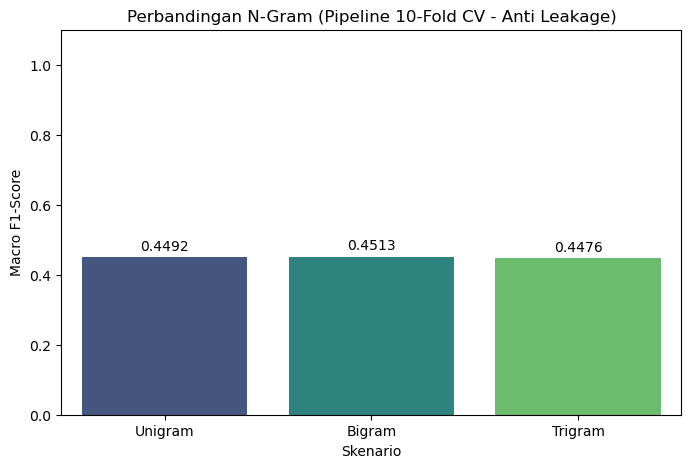


Kombinasi n-gram terbaik adalah: (1, 2)
Fitting ulang pipeline terbaik ke seluruh data training...
Vectorizer berhasil disimpan!
Data siap untuk tahap Hyperparameter Tuning!


In [29]:
# --- TAHAP 2: PERBANDINGAN N-GRAM (PIPELINE + CROSS-VALIDATION) ---

ngram_scenarios = {
    'Unigram': (1, 1),
    'Bigram': (1, 2),
    'Trigram': (1, 3)
}

results = []
best_score_cv = 0
best_ngram_range = (1, 1)
best_pipeline_obj = None # Wadah buat nyimpen pipeline juara

print("=== MULAI PERBANDINGAN N-GRAM (PIPELINE ANTI-LEAKAGE) ===")

for name, ngram in ngram_scenarios.items():
    print(f"Menguji skenario: {name}...")

    # 1. Definisikan Pipeline
    # Alur: Text Mentah -> TF-IDF -> SMOTE -> Naive Bayes
    pipe = ImbPipeline([
        ('tfidf', TfidfVectorizer(
            ngram_range=ngram, 
            max_features=5000, 
            min_df=5, 
            max_df=0.90)),
        ('smote', SMOTE(random_state=42, k_neighbors=3)), # SMOTE standar k=3
        ('clf', MultinomialNB())
    ])

    # 2. Evaluasi pakai Cross-Validation (Langsung dari X_train_text)
    # Pipeline akan otomatis split data -> TF-IDF -> SMOTE (hanya di train fold) -> Predict
    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    
    # Perhatikan: Inputnya X_train_text (teks mentah), bukan vector
    cv_scores = cross_val_score(pipe, X_train_text, y_train, cv=cv, scoring='f1_macro', n_jobs=-1)
    avg_score = cv_scores.mean()

    # Catat Hasil
    results.append({'Skenario': name, 'Rata-rata CV Score': avg_score})
    print(f"--> Rata-rata CV Score: {avg_score:.4f}")

    # Cari Pemenang
    if avg_score > best_score_cv:
        best_score_cv = avg_score
        best_ngram_range = ngram
        best_pipeline_obj = pipe # Simpan settingan pipeline pemenang

# === VISUALISASI ===
print("\n=== KESIMPULAN PERBANDINGAN ===")
df_results = pd.DataFrame(results)
print(df_results)

plt.figure(figsize=(8, 5))
ax = sns.barplot(
    x='Skenario',
    y='Rata-rata CV Score',
    data=df_results,
    palette='viridis',
    hue='Skenario',
    legend=False
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.4f', padding=3)

plt.title('Perbandingan N-Gram (Pipeline 10-Fold CV - Anti Leakage)')
plt.ylim(0, 1.1)
plt.ylabel('Macro F1-Score')
plt.show()

print(f"\nKombinasi n-gram terbaik adalah: {best_ngram_range}")

# --- PENTING: FIT ULANG UNTUK AMBIL VECTORIZER ---
# Karena tadi cuma cross_val, pipeline belum di-fit ke seluruh data.
# Kita harus fit manual ke seluruh X_train_text biar kita bisa ambil 'best_vectorizer'-nya buat Tahap 3.
print("Fitting ulang pipeline terbaik ke seluruh data training...")
best_pipeline_obj.fit(X_train_text, y_train)

# Ambil Vectorizer dari dalam pipeline (Langkah 'tfidf')
best_vectorizer = best_pipeline_obj.named_steps['tfidf']

print("Vectorizer berhasil disimpan!")
print("Data siap untuk tahap Hyperparameter Tuning!")

### Cek Penanganan Imbalance (SMOTE)

In [30]:
# Cek apakah data juara sudah seimbang?
#print("=== VERIFIKASI DATA FINAL SETELAH TURNAMEN ===")
#print(f"Distribusi Label Final (y_train_resampled): {Counter(y_train_resampled)}")
#print(f"Ukuran Matrix Final (X_train_resampled): {X_train_resampled.shape}")

# Tahap 3: Hyperparameter Tuning

=== TAHAP 3: TUNING PIPELINE (ANTI-LEAKAGE) ===
Menggunakan N-Gram Terbaik dari Tahap 2: (1, 2)
Sedang mencari kombinasi SMOTE & Alpha terbaik...
(Proses ini melatih model berulang kali pada data asli, mohon tunggu...)
Fitting 10 folds for each of 48 candidates, totalling 480 fits

=== HASIL HYPERPARAMETER TUNING (FINAL) ===
SMOTE k_neighbors Terbaik : 4
Alpha Terbaik             : 0.8
Fit Prior Terbaik         : True
Skor Validasi (Real Data) : 0.4569


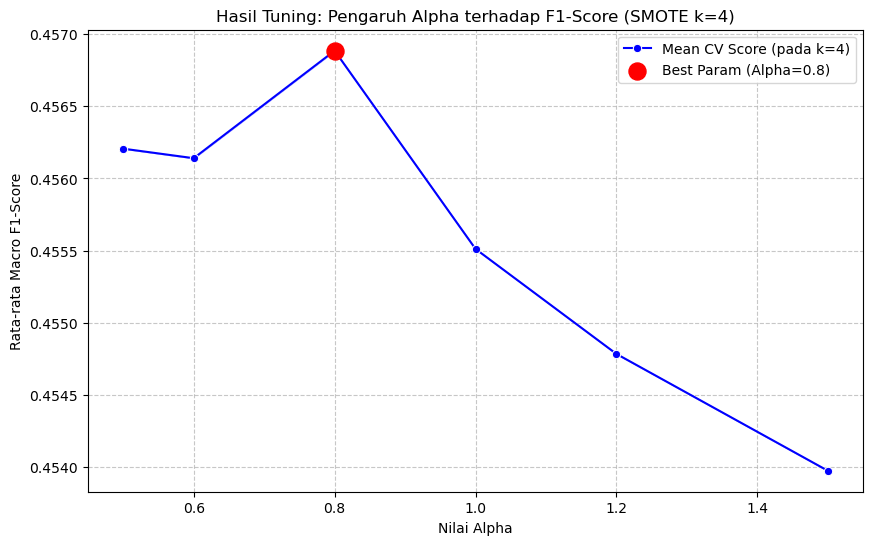


Model pipeline terbaik tersimpan di variabel 'best_model_pipeline'.


In [31]:
# --- TAHAP 3: HYPERPARAMETER TUNING (PIPELINE: SMOTE + ALPHA) ---
from imblearn.pipeline import Pipeline as ImbPipeline

print("=== TAHAP 3: TUNING PIPELINE (ANTI-LEAKAGE) ===")
print(f"Menggunakan N-Gram Terbaik dari Tahap 2: {best_ngram_range}")

# 1. Definisikan Pipeline Tuning
# Kita bangun ulang pipeline menggunakan N-Gram pemenang dari Tahap 2
pipeline_tuning = ImbPipeline([
    ('tfidf', TfidfVectorizer(
        ngram_range=best_ngram_range, # PENTING: Pakai hasil Tahap 2
        max_features=5000, 
        min_df=5, 
        max_df=0.90
    )),
    ('smote', SMOTE(random_state=42)), # Parameternya akan di-tune di bawah
    ('clf', MultinomialNB())           # Parameternya akan di-tune di bawah
])

# 2. Setup Parameter Grid (Gabungan SMOTE & Alpha)
# Format: 'nama_step__nama_parameter'
param_grid = {
    # Tuning SMOTE (Cari tetangga paling optimal)
    'smote__k_neighbors': [3, 4, 5, 7],
    
    # Tuning Naive Bayes (Cari smoothing terbaik)
    # Kita hindari 0.1 agar tidak overfitting
    'clf__alpha': [0.5, 0.6, 0.8, 1.0, 1.2, 1.5],
    'clf__fit_prior': [True, False]
}

# 3. Inisialisasi Grid Search
print("Sedang mencari kombinasi SMOTE & Alpha terbaik...")
print("(Proses ini melatih model berulang kali pada data asli, mohon tunggu...)")

grid_search = GridSearchCV(
    estimator=pipeline_tuning,
    param_grid=param_grid,
    cv=10,               # 10-Fold Cross Validation
    scoring='f1_macro',  # Tetap fokus ke Macro F1
    n_jobs=-1,           # Gunakan semua core CPU
    verbose=1
)

# 4. Latih dengan DATA MENTAH (X_train_text)
# Pipeline akan otomatis melakukan: TF-IDF -> SMOTE -> NB di dalam setiap fold
grid_search.fit(X_train_text, y_train)

# 5. Tampilkan Hasil Terbaik
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print("\n" + "="*40)
print("=== HASIL HYPERPARAMETER TUNING (FINAL) ===")
print("="*40)
print(f"SMOTE k_neighbors Terbaik : {best_params['smote__k_neighbors']}")
print(f"Alpha Terbaik             : {best_params['clf__alpha']}")
print(f"Fit Prior Terbaik         : {best_params['clf__fit_prior']}")
print(f"Skor Validasi (Real Data) : {best_score:.4f}")

# Simpan Model & Pipeline Terbaik
best_model_pipeline = grid_search.best_estimator_

# === VISUALISASI ===
# Kita buat grafik khusus untuk melihat pengaruh Alpha pada k_neighbors terbaik
results_df = pd.DataFrame(grid_search.cv_results_)

# Filter data: Ambil hanya baris di mana k_neighbors adalah yang terpilih
best_k = best_params['smote__k_neighbors']
filtered_df = results_df[results_df['param_smote__k_neighbors'] == best_k].copy()

# Konversi tipe data untuk plotting
filtered_df['param_clf__alpha'] = filtered_df['param_clf__alpha'].astype(float)

plt.figure(figsize=(10, 6))

# Plot Garis
sns.lineplot(
    data=filtered_df,
    x='param_clf__alpha',
    y='mean_test_score',
    marker='o',
    color='blue',
    label=f'Mean CV Score (pada k={best_k})'
)

# Tandai Titik Pemenang
plt.scatter(
    best_params['clf__alpha'],
    best_score,
    color='red',
    s=150,
    zorder=5,
    label=f"Best Param (Alpha={best_params['clf__alpha']})"
)

plt.title(f'Hasil Tuning: Pengaruh Alpha terhadap F1-Score (SMOTE k={best_k})')
plt.xlabel('Nilai Alpha')
plt.ylabel('Rata-rata Macro F1-Score')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

# Update Data Test untuk Tahap 4 (Skenario 5)
# Kita tidak perlu X_test_tfidf manual lagi, karena nanti kita predict pakai pipeline langsung
print("\nModel pipeline terbaik tersimpan di variabel 'best_model_pipeline'.")

# Tahap 4: Evaluasi Final & Komparasi Skenario

=== MEMULAI PENGUJIAN 5 SKENARIO (ABLATION STUDY) ===

[1/5] Running Skenario 1: Baseline (Raw Data)...

[2/5] Running Skenario 2: +Preprocessing (Slang/Stemming)...

[3/5] Running Skenario 3: +Feature n-gram (1, 2)...

[4/5] Running Skenario 4: +SMOTE Resampling...

[5/5] Running Skenario 5: +Hyperparameter Tuning...

REKAPITULASI HASIL PENGUJIAN 5 SKENARIO
           Skenario            Fokus  Macro F1   Akurasi
0       1. Baseline         Raw Data  0.321020  0.928751
1  2. Preprocessing       Clean Data  0.399443  0.929507
2   3. Fitur N-Gram       Contextual  0.370755  0.928751
3     4. Resampling    Balanced Data  0.469316  0.776183
4   5. Final Tuning  Optimized Model  0.466298  0.777946


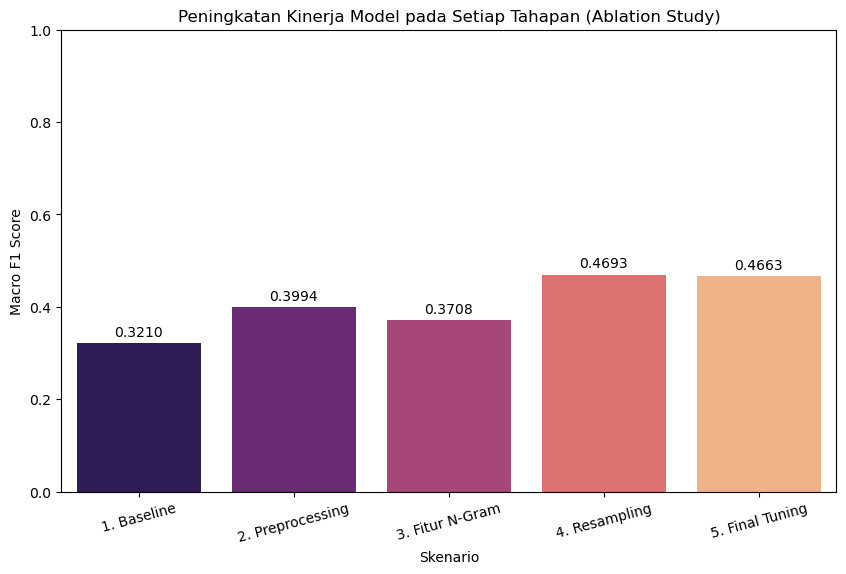


DETAIL PERFORMA MODEL TERBAIK (SKENARIO 5):
              precision    recall  f1-score   support

     Negatif       0.21      0.75      0.33        97
      Netral       0.12      0.41      0.19       186
     Positif       0.98      0.80      0.88      3689

    accuracy                           0.78      3972
   macro avg       0.44      0.65      0.47      3972
weighted avg       0.92      0.78      0.83      3972



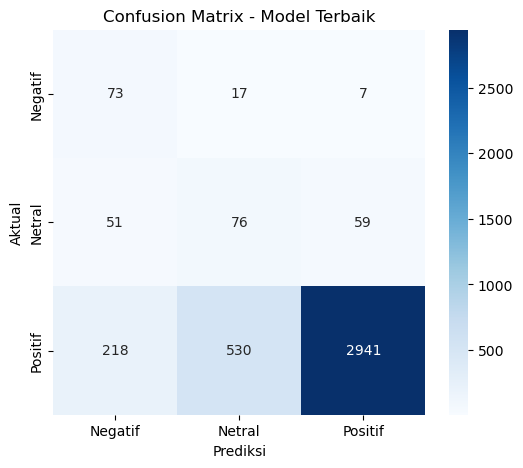

In [32]:
# --- TAHAP 4: EVALUASI PERFORMA 5 SKENARIO (FINAL) ---
from sklearn.metrics import classification_report, confusion_matrix

# Wadah untuk menampung hasil tabel
komparasi_results = []

print("=== MEMULAI PENGUJIAN 5 SKENARIO (ABLATION STUDY) ===")

# --- Skenario 1: BASELINE (Raw Text + Unigram + Tanpa SMOTE + Default NB) ---
print("\n[1/5] Running Skenario 1: Baseline (Raw Data)...")

# Tokenizer manual sederhana (spasi)
def raw_tokenizer(text):
    return text.split()

# Kita buat vectorizer baru khusus baseline (sesuai definisi raw)
vec_1 = TfidfVectorizer(
    tokenizer=raw_tokenizer,
    token_pattern=None,
    lowercase=False,
    min_df=1,
    max_features=None
)
# Gunakan data RAW (X_train_raw)
X_train_1 = vec_1.fit_transform(X_train_raw) 
X_test_1 = vec_1.transform(X_test_raw)

mnb_1 = MultinomialNB() # Default Alpha=1.0
mnb_1.fit(X_train_1, y_train)
pred_1 = mnb_1.predict(X_test_1)

komparasi_results.append({
    'Skenario': '1. Baseline',
    'Fokus': 'Raw Data',
    'Macro F1': f1_score(y_test, pred_1, average='macro'),
    'Akurasi': accuracy_score(y_test, pred_1)
})

# --- Skenario 2: EFEK PREPROCESSING (Clean Text + Unigram + Tanpa SMOTE + Default NB) ---
print("\n[2/5] Running Skenario 2: +Preprocessing (Slang/Stemming)...")
vec_2 = TfidfVectorizer(
    ngram_range=(1,1),
    max_features=5000,
    min_df=5,
    max_df=0.90
)
# Gunakan data CLEAN (X_train_text)
X_train_2 = vec_2.fit_transform(X_train_text) 
X_test_2 = vec_2.transform(X_test_text)

mnb_2 = MultinomialNB()
mnb_2.fit(X_train_2, y_train)
pred_2 = mnb_2.predict(X_test_2)

komparasi_results.append({
    'Skenario': '2. Preprocessing',
    'Fokus': 'Clean Data',
    'Macro F1': f1_score(y_test, pred_2, average='macro'),
    'Akurasi': accuracy_score(y_test, pred_2)
})

# --- SKENARIO 3: EFEK FITUR (Clean + n-gram Terbaik + Tanpa SMOTE + Default NB) ---
print(f"\n[3/5] Running Skenario 3: +Feature n-gram {best_ngram_range}...")

# Ambil Vectorizer dari dalam pipeline terbaik (Tahap 3)
# 'best_model_pipeline' adalah pipeline juara dari Tahap 3
# Kita ambil langkah 'tfidf'-nya saja
vec_3 = best_model_pipeline.named_steps['tfidf']

X_train_3 = vec_3.fit_transform(X_train_text)
X_test_3 = vec_3.transform(X_test_text)

mnb_3 = MultinomialNB()
mnb_3.fit(X_train_3, y_train)
pred_3 = mnb_3.predict(X_test_3)

komparasi_results.append({
    'Skenario': '3. Fitur N-Gram',
    'Fokus': 'Contextual',
    'Macro F1': f1_score(y_test, pred_3, average='macro'),
    'Akurasi': accuracy_score(y_test, pred_3)
})

# --- SKENARIO 4: EFEK RESAMPLING (Clean + n-gram + SMOTE + Default NB) ---
print("\n[4/5] Running Skenario 4: +SMOTE Resampling...")

# Kita gunakan data dari Skenario 3 (X_train_3) agar fiturnya sama
# Lakukan SMOTE secara manual di sini (karena ini skenario tanpa tuning)
# Kita pakai k=3 (standar) atau pakai k dari hasil tuning juga boleh.
# Biar adil, kita pakai k standar (3) untuk menunjukkan "Default SMOTE" vs "Tuned SMOTE"
smote_4 = SMOTE(random_state=42, k_neighbors=3)
X_train_4, y_train_4 = smote_4.fit_resample(X_train_3, y_train)

mnb_4 = MultinomialNB() # Default Alpha=1.0
mnb_4.fit(X_train_4, y_train_4)
pred_4 = mnb_4.predict(X_test_3) # Test set sama dengan Skenario 3

komparasi_results.append({
    'Skenario': '4. Resampling',
    'Fokus': 'Balanced Data',
    'Macro F1': f1_score(y_test, pred_4, average='macro'),
    'Akurasi': accuracy_score(y_test, pred_4)
})

# --- SKENARIO 5: OPTIMASI FINAL (Pipeline: Clean + n-gram + SMOTE + Tuned Alpha) ---
print(f"\n[5/5] Running Skenario 5: +Hyperparameter Tuning...")

# PENTING:
# 'best_model_pipeline' adalah PIPELINE LENGKAP (TFIDF -> SMOTE -> NB)
# Jadi kita inputkan TEXT MENTAH (X_test_text), biar pipeline yang urus sisanya.
pred_5 = best_model_pipeline.predict(X_test_text)

komparasi_results.append({
    'Skenario': '5. Final Tuning',
    'Fokus': 'Optimized Model',
    'Macro F1': f1_score(y_test, pred_5, average='macro'),
    'Akurasi': accuracy_score(y_test, pred_5)
})

# === TAMPILKAN HASIL TABEL ===
print("\n" + "="*50)
print("REKAPITULASI HASIL PENGUJIAN 5 SKENARIO")
print("="*50)
df_komparasi = pd.DataFrame(komparasi_results)
print(df_komparasi)

# === VISUALISASI PERBANDINGAN ===
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    x='Skenario', 
    y='Macro F1', 
    data=df_komparasi, 
    palette='magma', 
    hue='Skenario', 
    legend=False
)

# Tambah label angka
for container in ax.containers:
    ax.bar_label(container, fmt='%.4f', padding=3)

plt.title('Peningkatan Kinerja Model pada Setiap Tahapan (Ablation Study)')
plt.ylim(0, 1.0) # Skala 0-1
plt.xticks(rotation=15)
plt.ylabel('Macro F1 Score')
plt.show()

# === PRINT REPORT FINAL ===
print("\nDETAIL PERFORMA MODEL TERBAIK (SKENARIO 5):")
print(classification_report(y_test, pred_5))

# Confusion Matrix Skenario 5
cm = confusion_matrix(y_test, pred_5)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negatif', 'Netral', 'Positif'], yticklabels=['Negatif', 'Netral', 'Positif'])
plt.title('Confusion Matrix - Model Terbaik')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()

Membuktikan perlunya penanganan *imbalance* dan model *Baseline* (Skenario 1) itu "malas" dan hanya menebak kelas Positif (Mayoritas) aja.

In [33]:
# Bukti "Majority Class Bias (Kenapa Baseline 0.32)"
print("=== ANALISIS DISTRIBUSI PREDIKSI ===")

# 1. Cek Sebaran Label Asli (Kunci Jawaban)
print("\n[1] Distribusi Label Asli (y_test):")
print(y_test.value_counts())

# 2. Cek Tebakan Baseline (Skenario 1)
print("\n[2] Distribusi Prediksi Baseline (Skenario 1):")
print(pd.Series(pred_1).value_counts())
# Analisis: Pasti isinya cuma "Positif" atau hanya ada sedikit 'Netral" dan "Negatif"

# 3. Cek Tebakan Final (Skenario 5)
print("\n[3] Distribusi Prediksi Final (Skenario 5):")
print(pd.Series(pred_5).value_counts())
# Analisis: Pasti sudah banyak "Negatif" atau 'Netral" yang muncul

=== ANALISIS DISTRIBUSI PREDIKSI ===

[1] Distribusi Label Asli (y_test):
Sentiment_Label
Positif    3689
Netral      186
Negatif      97
Name: count, dtype: int64

[2] Distribusi Prediksi Baseline (Skenario 1):
Positif    3972
Name: count, dtype: int64

[3] Distribusi Prediksi Final (Skenario 5):
Positif    3007
Netral      623
Negatif     342
Name: count, dtype: int64


Menunjukkan keunggulan metode *Preprocessing* dan *Filtering* dan membuktikan Skenario 2 & 3 itu "hemat memori" dibanding Skenario 1.

=== EFISIENSI MODEL ===
Fitur Awal (Kotor): 19444
Fitur Akhir (Optimal): 2645
Penghematan Dimensi: 86.4%


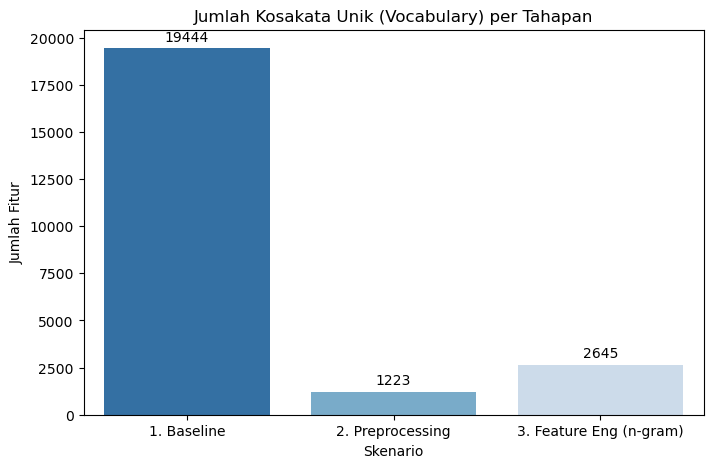

In [34]:
# Bukti Efisiensi (Perbandingan Jumlah Fitur/Vocab)
vocab_stats = [
    {'Skenario': '1. Baseline', 'Jumlah Fitur': len(vec_1.vocabulary_)},
    {'Skenario': '2. Preprocessing', 'Jumlah Fitur': len(vec_2.vocabulary_)},
    {'Skenario': '3. Feature Eng (n-gram)', 'Jumlah Fitur': len(vec_3.vocabulary_)},
    # Skenario 4 & 5 sama dengan 3 jumlah fiturnya.
]

df_vocab = pd.DataFrame(vocab_stats)

# Hitung Persentase Pengurangan
baseline_count = df_vocab.iloc[0]['Jumlah Fitur']
final_count = df_vocab.iloc[2]['Jumlah Fitur']
hemat = ((baseline_count - final_count) / baseline_count) * 100

print(f"=== EFISIENSI MODEL ===")
print(f"Fitur Awal (Kotor): {baseline_count}")
print(f"Fitur Akhir (Optimal): {final_count}")
print(f"Penghematan Dimensi: {hemat:.4}%")

# Plotting
plt.figure(figsize=(8, 5))
ax = sns.barplot(
    x='Skenario', 
    y='Jumlah Fitur', 
    data=df_vocab, 
    palette='Blues_r',
    hue='Skenario')
for c in ax.containers: ax.bar_label(c, fmt='%d', padding=3)
plt.title('Jumlah Kosakata Unik (Vocabulary) per Tahapan')
plt.ylabel('Jumlah Fitur')
plt.show()

**<h3>Visualisasi Confusion Matrix</h3>**
Memperlihatkan secara visual bahwa model Final berhasil mendeteksi kotak "Negatif dan "Netral", serta melihat seberapa banyak model "salah tebak" untuk dibandingkan Sebelum (Baseline) vs Sesudah (Final).

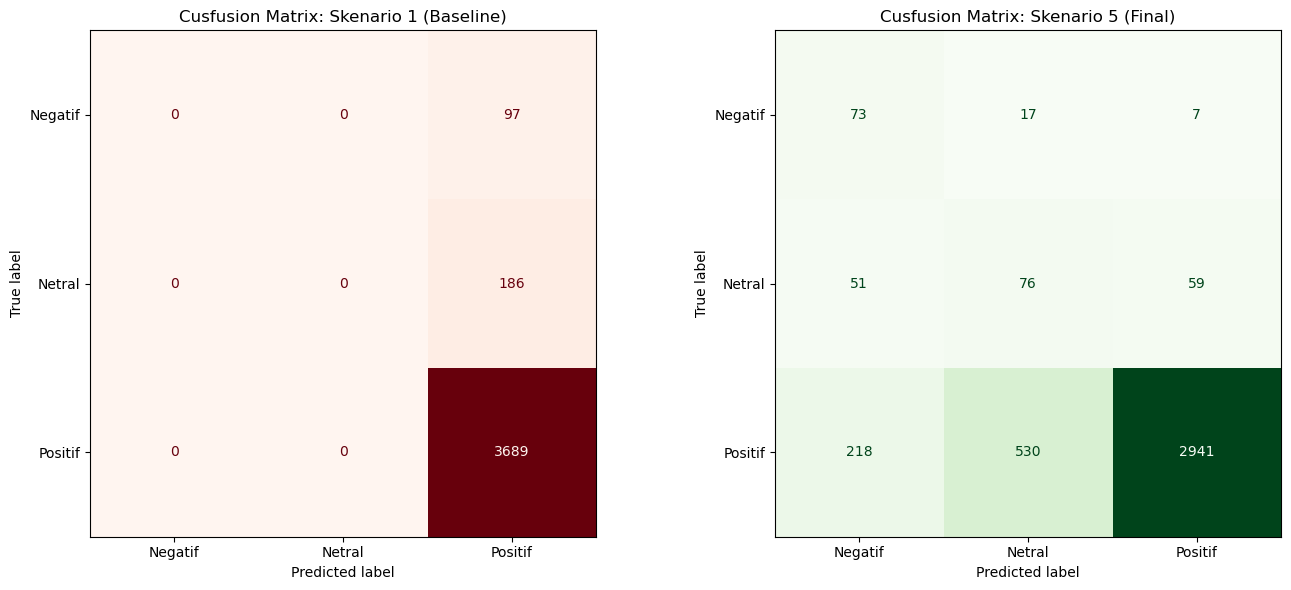

In [35]:
# Atur label urut agar rapi
labels = ['Negatif', 'Netral', 'Positif']

fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# plot 1: Baseline
cm_1 = confusion_matrix(y_test, pred_1, labels=labels)
disp_1 = ConfusionMatrixDisplay(confusion_matrix=cm_1, display_labels=labels)
disp_1.plot(cmap='Reds', ax=ax[0], colorbar=False)
ax[0].set_title('Cusfusion Matrix: Skenario 1 (Baseline)')

# plot 5: Final (Skenario 5)
cm_5 = confusion_matrix(y_test, pred_5, labels=labels)
disp_5 = ConfusionMatrixDisplay(confusion_matrix=cm_5, display_labels=labels)
disp_5.plot(cmap='Greens', ax=ax[1], colorbar=False)
ax[1].set_title('Cusfusion Matrix: Skenario 5 (Final)')

plt.tight_layout()
plt.show()

**<h3>Insight Fitur: Kata apa yang paling "Positif" & "Negatif"</h3>**
Tujuannya untuk memvalidasi secara kualitatif (misalnya: membuktikan bahwa kata "rusak" benar-benar dianggap negatif oleh model)

In [36]:
# --- ANALISIS FITUR TERPENTING ---
print("=== ANALISIS KATA KUNCI SENTIMEN ===")

def analyze_top_features(vectorizer, model, n=10):
    feature_names = vectorizer.get_feature_names_out()
    classes = model.classes_
    table_data = {}
    
    # Plotting
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    
    for i, label in enumerate(classes):
        top_indices = np.argsort(model.feature_log_prob_[i])[-n:]
        top_features = [feature_names[j] for j in top_indices]
        top_weights = model.feature_log_prob_[i][top_indices]
        
        # Simpan ke Tabel
        table_data[f"{label} (Kata)"] = top_features[::-1]
        table_data[f"{label} (Bobot)"] = [f"{w:.2f}" for w in top_weights[::-1]]
        
        # Plot Grafik
        axes[i].barh(top_features, top_weights, color=sns.color_palette("viridis", n))
        axes[i].set_title(f"Kelas: {label}")
        axes[i].set_xlabel("Log Probability")
    
    plt.tight_layout()
    plt.show()
    return pd.DataFrame(table_data)

# [PENTING] Pakai 'best_vectorizer' di sini!
# 'best_model' didapat dari tahap Hyperparameter Tuning
if 'best_vectorizer' in locals() and 'best_model' in locals():
    df_top_words = analyze_top_features(best_vectorizer, best_model_pipeline, n=10)
    print("\n=== TABEL KATA KUNCI ===")
    display(df_top_words)
else:
    print("Error: Variabel 'best_vectorizer' atau 'best_model' belum ada. Run tahap sebelumnya dulu.")

=== ANALISIS KATA KUNCI SENTIMEN ===
Error: Variabel 'best_vectorizer' atau 'best_model' belum ada. Run tahap sebelumnya dulu.
